In [1]:
import time
import random
import copy

from enum import Enum
from typing import Tuple, Union

import networkx as nx
import numpy as np

import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output

# GoMoKu simulator
- Gomoku is a popular game played in many countries. The player wins by having their pieces forming a straight-line connection with the length of 5 in an 8x8 board. The connection can be either horizontal, vertical or diagonal.

- However, in this assignment, the player **wins by having their symbol forming a connection with the length of 3 in 3x3 board**. The connection can be either horizontal, vertical or diagonal.

- **In the following blocks, Jupyter Notebook blocks are provided to define the necessary elements for implementing the Gomoku game. You can execute them one by one to become familiar with the components.**

Define datatye for game result

In [2]:
class GameResult(Enum):
  """
  Enum to encode different states of the game. A game can be in progress (NOT_FINISHED), lost, won, or draw
  """
  NOT_FINISHED = 0
  NAUGHT_WIN = 1
  CROSS_WIN = 2
  DRAW = 3

Define board and game hyperparameter
- Board size
- The length of a connection for winning

In [3]:
BOARD_DIM = 3 # type: int
BOARD_SIZE = BOARD_DIM * BOARD_DIM  # type: int
NUM_WIN = 3

Board consists of cells
- There are two symbols
  - Naught: O
  - Cross: X

In [4]:
class CellState(Enum):
  EMPTY = 0  # type: int
  NAUGHT = 1  # type: int
  CROSS = 2  # type: int

Gomoku Board

In [5]:
class GomokuBoard:
    """
    The class to encode a gomoku board, including its current state of pieces.
    Also contains various utility methods.
    """

    WIN_CHECK_DIRS = [[(-1, 0), (1, 0)],
                      [(0, -1), (0, 1)],
                      [(-1, 1), (1, -1)],
                      [(-1, -1), (1, 1)]]

    def hash_value(self) -> int:
        """
        Encode the current state of the game (board positions) as an integer. Will be used for caching evaluations
        :return: A collision free hash value representing the current board state
        """
        res = 0
        for i in range(BOARD_SIZE):
            res *= BOARD_DIM
            res += self.state[i].value

        return res

    @staticmethod
    def other_side(side: CellState) -> CellState:
        """
        Utility method to return the value of the other player than the one passed as input
        :param side: The side we want to know the opposite of
        :return: The opposite side to the one passed as input
        """
        if side == CellState.EMPTY:
            raise ValueError("EMPTY has no 'other side'")

        if side == CellState.CROSS:
            return CellState.NAUGHT

        if side == CellState.NAUGHT:
            return CellState.CROSS

        raise ValueError("{} is not a valid side".format(side))

    def __init__(self):
        """
        Create a new Board. If a state is passed in, we use that otherwise we initialize with an empty board
        :param s: Optional board state to initialise the board with
        """
        self.state = np.ndarray(shape=(BOARD_SIZE,), dtype=CellState)
        self.reset()

    def coord_to_pos(self, coord: Tuple[int, int]) -> int:
        """
        Converts a 2D board position to a 1D board position.
        Various parts of code prefer one over the other.
        :param coord: A board position in 2D coordinates
        :return: The same board position in 1D coordinates
        """
        return coord[0] * BOARD_DIM + coord[1]

    def pos_to_coord(self, pos: int) -> Tuple[int, int]:
        """
        Converts a 1D board position to a 2D board position.
        Various parts of code prefer one over the other.
        :param pos: A board position in 1D coordinates
        :return: The same board position in 2D coordinates
        """
        return pos // BOARD_DIM, pos % BOARD_DIM

    def reset(self):
        """
        Resets the game board. All fields are set to be EMPTY.
        """
        self.state.fill(CellState.EMPTY)
        self.who_won = None

    def num_empty(self) -> int:
        """
        Counts and returns the number of empty fields on the board.
        :return: The number of empty fields on the board
        """
        return np.count_nonzero(self.state == CellState.EMPTY)

    def random_empty_spot(self) -> int:
        """
        Returns a random empty spot on the board in 1D coordinates
        :return: A random empty spot on the board in 1D coordinates
        """
        index = np.random.randint(self.num_empty()) # Count all empty spot and random selection among them
        for i in range(BOARD_SIZE):
            if self.state[i] == CellState.EMPTY:
                if index == 0: # if index is zero, then, it means this spot is selected
                    return i
                else:
                    index = index - 1 # if index is not zero, then, it means we have to move next emtpy spot

    def is_legal(self, pos: int) -> bool:
        """
        Tests whether a board position can be played, i.e. is currently empty
        :param pos: The board position in 1D that is to be checked
        :return: Whether the position can be played
        """
        return (0 <= pos < BOARD_SIZE) and (self.state[pos] == CellState.EMPTY)

    def move(self, position: int, side: CellState) -> Union[np.ndarray, GameResult, bool]:
        """
        Places a piece of side "side" at position "position". The position is to be provided as 1D.
        Throws a ValueError if the position is not EMPTY
        returns the new state of the board, the game result after this move, and whether this move has finished the game

        :param position: The position where we want to put a piece
        :param side: What piece we want to play (NAUGHT, or CROSS)
        :return: The game state after the move, The game result after the move, Whether the move finished the game
        """
        if self.state[position] != CellState.EMPTY:
            print('Illegal move')
            raise ValueError("Invalid move")

        self.state[position] = side

        if self.check_win(position, side):
            self.who_won = side
            return self.state, GameResult.CROSS_WIN if side == CellState.CROSS else GameResult.NAUGHT_WIN, True

        if self.num_empty() == 0:
            self.who_won = CellState.EMPTY
            return self.state, GameResult.DRAW, True

        return self.state, GameResult.NOT_FINISHED, False

    def check_win(self, pos: int, side: CellState):
        row = pos // BOARD_DIM
        col = pos % BOARD_DIM

        def check_direction(_dr, _dc):
            count = 0
            r, c = row + _dr, col + _dc
            p = r * BOARD_DIM + c
            while 0 <= r < BOARD_DIM and 0 <= c < BOARD_DIM and self.state[p] == side:
                count += 1
                r += _dr
                c += _dc
                p = r * BOARD_DIM + c
            return count

        directions = [(1, 0), (0, 1), (1, 1), (1, -1)]

        for dr, dc in directions:
            total_count = 1  # Count the current stone
            total_count += check_direction(-dr, -dc)  # Count stones in the opposite direction
            total_count += check_direction(dr, dc)    # Count stones in the original direction

            if total_count >= NUM_WIN:
                return True

        return False

    def state_to_char(self, pos):
        """
        Return 'x', 'o', or ' ' depending on what piece is on 1D position pos. Ig `html` is True,
        return '&ensp' instead of ' ' to enforce a white space in the case of HTML output
        :param pos: The position in 1D for which we want a character representation
        :param html: Flag indicating whether we want an ASCII (False) or HTML (True) character
        :return: 'x', 'o', or ' ' depending on what piece is on 1D position pos. Ig `html` is True,
        return '&ensp' instead of ' '
        """
        if (self.state[pos]) == CellState.NAUGHT:
            return 'O'
        elif (self.state[pos]) == CellState.CROSS:
            return 'X'

Visualizing a board
- Clear all figures and prints before drawing a board


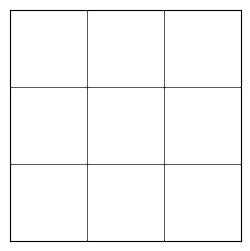

In [6]:
def draw_go_board(board: GomokuBoard):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(BOARD_DIM, BOARD_DIM))
    ax.set_xlim(0, BOARD_DIM)
    ax.set_ylim(0, BOARD_DIM)

    cell_size = 0.97
    rect_offset = (1.-cell_size) / 2  # Offset to center the cells
    offset = 1 / 2

    # Draw black board
    ax.add_patch(plt.Rectangle((0, 0), BOARD_DIM, BOARD_DIM, color='black', fill=True))

    # Draw white cells
    for x in range(BOARD_DIM):
        for y in range(BOARD_DIM):
            ax.add_patch(plt.Rectangle((x + rect_offset, y + rect_offset), cell_size, cell_size, color='white', fill=True))

    # Place markers
    for x in range(BOARD_DIM):
        for y in range(BOARD_DIM):
            pos = x * BOARD_DIM + y
            marker = board.state_to_char(pos)
            ax.text(x + offset, y + offset, marker, ha='center', va='center', fontsize=20)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    plt.show()
    time.sleep(0.5)

board = GomokuBoard()
draw_go_board(board)

Select an empty cell from random policy
- It means that a random policy is given!

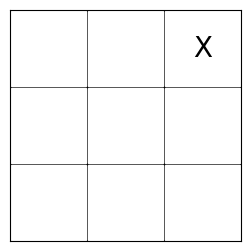

In [ ]:
location = board.random_empty_spot()
_, res, finished = board.move(int(location), CellState.CROSS)
draw_go_board(board)

Check winning conditions!
- Board class has a _move method_ whose inputs are "location and side" and outpus are "results of game and finish or not"



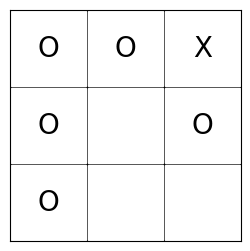

GameResult.NAUGHT_WIN


In [ ]:
finished = False
while not finished:
    location = board.random_empty_spot()
    _, res, finished = board.move(int(location), CellState.NAUGHT)
    draw_go_board(board)
    print(res)

# Agent class definition

- The provided class, **GamePlayerInterface**, is an abstract class in Python, defined using the ABC (Abstract Base Class) module.
This class serves as an interface or template for implementing Gomoku players in a Gomoku game. Let's break down the key components and purpose of this class:

- Abstract Methods: The GamePlayerInterface class contains several abstract methods, indicated by the @abstractmethod decorator. Abstract methods are methods that are declared but not implemented in the base class. Instead, derived classes must provide concrete implementations for these methods. Let's go through each of the abstract methods:

  - _move(self, board: GomokuBoard) -> Union[GameResult, bool]_:
  
   This method represents the player's move in the Gomoku game. It takes a GomokuBoard object as a parameter, which likely represents the current state of the game board. The method returns either a GameResult or a boolean value. The GameResult may represent the outcome of the game after the move, such as a win or a draw. The boolean value may indicate whether the move was successful.

  - _new_game(self, side: CellState)_:

   This method is meant to be called when a new game of Gomoku is starting. It takes a side parameter, which likely represents the player's side or symbol (e.g., 'X' or 'O'). Derived classes should implement this method to prepare for a new game.

In [7]:
from abc import ABC, abstractmethod

class GamePlayerInterface(ABC):
    """
    Interface for Gomoku player
    """
    def __init__(self):
        super().__init__()

    @abstractmethod
    def move(self, board: GomokuBoard) -> Union[GameResult, bool]:
        pass

    @abstractmethod
    def new_game(self, side: CellState):
        pass

Example: random agent!

In [8]:
class RandomPlayer(GamePlayerInterface):
    def __init__(self):
        # Initialize the player's side to None
        self.side = None
        super().__init__()

    def move(self, GomokuBoard: GomokuBoard) -> Union[GameResult, bool]:
        # Get a random empty spot on the game board
        location = GomokuBoard.random_empty_spot()

        # Make a move on the game board and capture the result and whether the game is finished
        _, res, finished = GomokuBoard.move(int(location), self.side)

        # Return the move's result and whether the game is finished
        return res, finished

    def new_game(self, side: CellState):
        # Set the player's side at the start of a new game
        self.side = side

Helper functions

1. Play a game
   - This function simulates a single Gomoku game between two players represented by the player1 and player2 objects, using the game board provided as board.

   - It starts by initializing the players for a new game, with player1 taking the 'CROSS' side and player2 taking the 'NAUGHT' side.

   - The game board is reset to an empty state.

   - The function enters a loop where the players take turns making moves on the board until the game is finished. After each move, if the drawing_board parameter is set to True, it also visualizes the current state of the game board using the draw_go_board function (which is assumed to be defined elsewhere).

   - The function returns the result of the game (whether 'CROSS' or 'NAUGHT' won or if it's a draw).
2. Battle

   - This function simulates a series of Gomoku games between two players, player1 and player2, for a specified number of games (num_games).

   - It initializes a Gomoku board for each game and keeps track of the number of wins for 'CROSS' (player1), 'NAUGHT' (player2), and draws.

   - The games are played by calling the play_game function repeatedly with the provided players.

   - After all games are played, the function prints out the results, including the number of draws, wins for 'CROSS' (player1), and wins for 'NAUGHT' (player2). If the silent parameter is set to True, it doesn't print the results.

   - The function also calculates and prints the percentages of draws and wins for each player based on the total number of games played.

In [9]:
def play_game(board: GomokuBoard, player1: GamePlayerInterface, player2: GamePlayerInterface, drawing_board: bool = True):
    player1.new_game(CellState.CROSS)
    player2.new_game(CellState.NAUGHT)
    board.reset()

    finished = False
    while not finished:
        result, finished = player1.move(board)
        if drawing_board:
            draw_go_board(board)
        if finished:
            continue
        else:
            result, finished = player2.move(board)
            if drawing_board:
                draw_go_board(board)
    return result

def battle(player1: GamePlayerInterface, player2: GamePlayerInterface, num_games: int = 1000, silent: bool = False):
    board = GomokuBoard()
    draw_count = 0
    cross_count = 0
    naught_count = 0
    for _ in range(num_games):
        result = play_game(board, player1, player2, drawing_board=False)
        if result == GameResult.CROSS_WIN:
            cross_count += 1
        elif result == GameResult.NAUGHT_WIN:
            naught_count += 1
        else:
            draw_count += 1

    if not silent:
        print("After {} game we have draws: {}, GamePlayerInterface 1 wins: {}, and GamePlayerInterface 2 wins: {}.".format(num_games, draw_count,
                                                                                                  cross_count,
                                                                                                  naught_count))

        print("Which gives percentages of draws: {:.2%}, GamePlayerInterface 1 wins: {:.2%}, and GamePlayerInterface 2 wins:  {:.2%}".format(
            draw_count / num_games, cross_count / num_games, naught_count / num_games))

    return cross_count, naught_count, draw_count

Run _play_game_ function!

- Random Policy vs. Random Policy

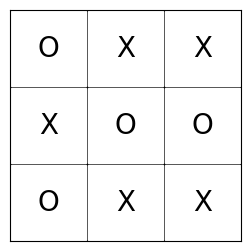

GameResult.DRAW


In [ ]:
board = GomokuBoard()
player1 = RandomPlayer()
player2 = RandomPlayer()
result = play_game(board, player1, player2)
print(result)

Estiamte win rate using battle function!
- It reports the average win rate among 1000 games

In [ ]:
board = GomokuBoard()
player1 = RandomPlayer()
player2 = RandomPlayer()
cross_count, naught_count, draw_count = battle(player1, player2)

After 1000 game we have draws: 116, GamePlayerInterface 1 wins: 607, and GamePlayerInterface 2 wins: 277.
Which gives percentages of draws: 11.60%, GamePlayerInterface 1 wins: 60.70%, and GamePlayerInterface 2 wins:  27.70%


# Implement Min-Max Tree Search!!!

**The instructions and skeletones are just guide line**

Here are the instructions for each part of the provided skeleton code in bullet points:

- new_game Method:

  - This method initializes the MinMaxAlgorithm for a new game. Set the player's side to the value of the side parameter. Clear the game tree.

- find_optimal_move Method:

  - Implement the find_optimal_move function for the MinMax algorithm.
Retrieve successors of the current_node from the tree.
Initialize best_score to negative infinity for maximizing and positive infinity for minimizing.
Loop through successors and update best_score based on whether maximizing or minimizing.
Create a list of best_moves for equal evaluation scores.
Randomly choose one of the best_moves and return it along with best_score.
- _min Method:

  - Implement the Min function for the MinMax algorithm.
Check if the game is finished and return appropriate values (-1, 0, or 1) for best move if the game has already finished.
If the game is not finished, calculate the best move for the Min player and return the result.
- _max Method:

  - Implement the Max function for the MinMax algorithm.
Check if the game is finished and return appropriate values (-1, 0, or 1) for best move if the game has already finished.
If the game is not finished, calculate the best move for the Max player and return the result.
- move Method:

  - Implement the move function for the MinMax algorithm.
Calculate the best move for the current player using the MinMax algorithm (use _min and _max).
Make the move on the board and return the result of the move.

In [10]:
class MinMaxAlgorithm(GamePlayerInterface):
    """
    A computer player implementing the Min Max algorithm.
    """

    WIN_VALUE = 1
    DRAW_VALUE = 0
    LOSS_VALUE = -1

    def __init__(self):
        self.side = None
        self.tree = nx.DiGraph()
        super().__init__()

    def new_game(self, side: CellState):
        """
        Setting the side for the game to come. Noting else to do.
        :param side: The side this player will be playing
        """
        self.side = side
        self.tree.clear()

    def find_optimal_move(self, current_node: nx.classes.graph.Graph, find_max: bool):
        """
        Find the optimal move based on the MinMax algorithm.

        :param current_node: The current node representing the board state in the game tree.
        :param find_max: A boolean indicating whether to find the maximum (True) or minimum (False) value.

        :return: A tuple containing the best score and the selected best move.
        """
        # TODO: Implement the find_optimal_move function for the MinMax algorithm
        #  - Retrieve successors of the current_node from the tree
        #  - Initialize best_score to negative infinity for maximizing and positive infinity for minimizing
        #  - Loop through successors and update best_score based on whether we're maximizing or minimizing
        #  - Create a list of best_moves for equal evaluation scores
        #  - Randomly choose one of the best_moves and return it along with best_score

        successors = list(self.tree.successors(current_node))

        if not successors:
            return (self.DRAW_VALUE, -1)

        if find_max:
            best_score = float('-inf')
        else:
            best_score = float('inf')

        best_moves = []

        for successor in successors:
            score = self.tree.nodes[successor].get("score", self.DRAW_VALUE)

            if (find_max and score > best_score) or (not find_max and score < best_score):
                best_score = score
                best_moves = [successor]
            elif score == best_score:
                best_moves.append(successor)

        if not best_moves:
            return (best_score, -1)

        best_move = random.choice(best_moves)
        move = self.tree.edges[current_node, best_move]['action']

        return (best_score, move)


    def _min(self, board: GomokuBoard) -> Union[float, int]:
        """
        Evaluate the board position `board` from the Minimizing player's point of view.

        :param board: The board position to evaluate
        :return: Tuple of (Best Result, Best Move in this situation). Returns -1 for best move if the game has already
        finished
        """
        # TODO: Implement the Min function for the MinMax algorithm
        #  - Check if the game is finished and return appropriate values
        #  - If not, calculate the best move for the Min player and return the result
        if board.who_won is not None:
            if board.who_won == self.side:
                return self.WIN_VALUE, -1
            elif board.who_won == CellState.EMPTY:
                return self.DRAW_VALUE, -1
            else:
                return self.LOSS_VALUE, -1
        best_score = float('inf')
        best_move = -1
        for pos in range(BOARD_SIZE):
            if board.is_legal(pos):
                new_board = copy.deepcopy(board)
                _, result, done = new_board.move(pos, GomokuBoard.other_side(self.side))
                if done:
                    if result == GameResult.DRAW:
                        score = self.DRAW_VALUE
                    elif result == GameResult.CROSS_WIN if self.side == CellState.NAUGHT else GameResult.NAUGHT_WIN:
                        score = self.LOSS_VALUE
                    else:
                        score = self.WIN_VALUE
                else:
                    score, _ = self._max(new_board)
                if score < best_score:
                    best_score = score
                    best_move = pos
        return best_score, best_move


    def _max(self, board: GomokuBoard) -> Union[float, int]:
        """
        Evaluate the board position `board` from the Maximizing player's point of view.

        :param board: The board position to evaluate
        :return: Tuple of (Best Result, Best Move in this situation). Returns -1 for best move if the game has already
        finished
        """
        # TODO: Implement the Max function for the MinMax algorithm
        #  - Check if the game is finished and return appropriate values
        #  - If not, calculate the best move for the Max player and return the result
        if board.who_won is not None:
            if board.who_won == self.side:
                return self.WIN_VALUE, -1
            elif board.who_won == CellState.EMPTY:
                return self.DRAW_VALUE, -1
            else:
                return self.LOSS_VALUE, -1
        best_score = float('-inf')
        best_move = -1
        for pos in range(BOARD_SIZE):
            if board.is_legal(pos):
                temp_board = copy.deepcopy(board)
                _, result, done = temp_board.move(pos, self.side)
                if done:
                    if result == GameResult.DRAW:
                        score = self.DRAW_VALUE
                    elif result == GameResult.CROSS_WIN if self.side == CellState.CROSS else GameResult.NAUGHT_WIN:
                        score = self.WIN_VALUE
                    else:
                        score = self.LOSS_VALUE
                else:
                    score, _ = self._min(temp_board)
                if score > best_score:
                    best_score = score
                    best_move = pos
        return best_score, best_move


    def move(self, board: GomokuBoard) -> Union[GameResult, bool]:
        """
        Making a move according to the MinMax algorithm

        :param board: The board to make a move on
        :return: The result of the move
        """
        # TODO: Implement the move function for the MinMax algorithm
        #  - Calculate the best move for the current player using the MinMax algorithm
        #  - Make the move on the board and return the result of the move
        _, best_move = self._max(board)
        if best_move == -1:
            raise RuntimeError("No legal move found!")
        _, res, finished = board.move(best_move, self.side)
        return res, finished


#Requirements

1. Submission Requirements
- You need to submit your class as a .py file
- **Your file must contain 'GamePlayerInterface' and 'MinMaxAlgorithm'**
- You can import any other libraries and add any other classes in your file
- Do not employ any other libraries for tree search algorithm except for "networkx"
- The Python file should be named with your student number, like this: min_max_tree_[student_number].py
- It should be importable and usable as follows:
```
import min_max_tree_[student_number]
player1 = min_max_tree_[student_number].MinMaxAlgorithm()
```
- For example, if your student number is 12345, then,
  - Your submission must be "min_max_tree_12345.py"
  - We can import your file as follows,
  ```
  import min_max_tree_12345
  player1 = min_max_tree_12345.MinMaxAlgorithm()
  ```

2. Performance Requirements

  You can check the performance of the implemented tree search using the battle function. The implemented min-max tree should meet the following requirements when competing against a random policy:

- When battling as player1 with random policy, achieve a win rate of 90% or higher (excluding draws)
- When battling as player2 with random policy, have a 0% probability of losing

In [12]:
player1 = MinMaxAlgorithm()
player2 = RandomPlayer()
cross_count, naught_count, draw_count = battle(player1, player2, num_games=10)

After 10 game we have draws: 0, GamePlayerInterface 1 wins: 10, and GamePlayerInterface 2 wins: 0.
Which gives percentages of draws: 0.00%, GamePlayerInterface 1 wins: 100.00%, and GamePlayerInterface 2 wins:  0.00%


In [13]:
player1 = RandomPlayer()
player2 = MinMaxAlgorithm()
cross_count, naught_count, draw_count = battle(player1, player2, num_games=10)

After 10 game we have draws: 2, GamePlayerInterface 1 wins: 0, and GamePlayerInterface 2 wins: 8.
Which gives percentages of draws: 20.00%, GamePlayerInterface 1 wins: 0.00%, and GamePlayerInterface 2 wins:  80.00%
